# Week 4: Backpropagation, SGD, and Regularization

**Lecture 7:** Backpropagation implementation  
**Lecture 8:** Stochastic gradient descent and regularization

# Lecture 7: Implementing Backpropagation

This implementation follows the equations from Week 3. The forward pass stores every activation. The backward pass computes the output delta, propagates deltas backward, and constructs explicit gradients for each $W^{(\ell)}$ and $b^{(\ell)}$.

Lecture 7 deliberately uses **full-batch gradient descent**: every update is computed from the complete training set. Lecture 8 will upgrade the class to use mini-batch SGD.

In [15]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [16]:
class MultilayerPerceptron:
    def __init__(self, layer_sizes, alpha=0.5, seed=1):
        self.alpha = alpha
        self.rng = np.random.default_rng(seed)
        self.weights = []
        self.biases = []

        for input_size, output_size in zip(layer_sizes[:-1], layer_sizes[1:]):
            scale = np.sqrt(2 / (input_size + output_size))
            self.weights.append(
                self.rng.normal(0, scale, size=(input_size, output_size))
            )
            self.biases.append(np.zeros(output_size))

    @staticmethod
    def sigmoid(z):
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

    @staticmethod
    def sigmoid_gradient(a):
        return a * (1 - a)

    @staticmethod
    def softmax(z):
        shifted_z = z - z.max(axis=1, keepdims=True)
        exp_z = np.exp(shifted_z)
        return exp_z / exp_z.sum(axis=1, keepdims=True)

    def forward(self, X):
        # Cache every layer activation because backpropagation reuses it.
        activations = [np.atleast_2d(X)]

        for layer, (W, b) in enumerate(zip(self.weights, self.biases)):
            z = activations[-1] @ W + b
            if layer == len(self.weights) - 1:
                a = self.softmax(z)
            else:
                a = self.sigmoid(z)
            activations.append(a)

        return activations

    def cross_entropy(self, X, y):
        probabilities = np.clip(self.forward(X)[-1], 1e-12, 1.0)
        return -np.mean(np.sum(y * np.log(probabilities), axis=1))

    def gradients(self, X, y):
        X = np.atleast_2d(X)
        y = np.atleast_2d(y)
        n = X.shape[0]
        activations = self.forward(X)

        weight_gradients = [None] * len(self.weights)
        bias_gradients = [None] * len(self.biases)

        # Softmax plus cross-entropy gives this explicit output delta.
        delta = activations[-1] - y

        for layer in range(len(self.weights) - 1, -1, -1):
            # Connect the previous activation to each unit's current error.
            weight_gradients[layer] = activations[layer].T @ delta / n
            bias_gradients[layer] = delta.mean(axis=0)

            if layer > 0:
                # Move the error through W, then through sigmoid's derivative.
                delta = (
                    delta @ self.weights[layer].T
                    * self.sigmoid_gradient(activations[layer])
                )

        return weight_gradients, bias_gradients

    def step(self, X, y):
        weight_gradients, bias_gradients = self.gradients(X, y)

        # Update every layer only after all of its gradients are available.
        for layer in range(len(self.weights)):
            self.weights[layer] -= self.alpha * weight_gradients[layer]
            self.biases[layer] -= self.alpha * bias_gradients[layer]

    def accuracy(self, X, y):
        targets = y.argmax(axis=1) if y.ndim == 2 else y
        return np.mean(self.predict(X) == targets)

    @staticmethod
    def print_history_header():
        print(
            f"{'epoch':>7} {'loss':>12} {'val_loss':>12} "
            f"{'accuracy':>12} {'val_accuracy':>14}"
        )
        print("-" * 63)

    def record_metrics(self, epoch, X, y, validation_data):
        X_val, y_val = validation_data
        metrics = {
            "epoch": epoch,
            "loss": self.cross_entropy(X, y),
            "val_loss": self.cross_entropy(X_val, y_val),
            "accuracy": self.accuracy(X, y),
            "val_accuracy": self.accuracy(X_val, y_val),
        }
        print(
            f"{metrics['epoch']:7d} {metrics['loss']:12.6f} "
            f"{metrics['val_loss']:12.6f} {metrics['accuracy']:12.4f} "
            f"{metrics['val_accuracy']:14.4f}"
        )
        return metrics

    def fit(self, X, y, validation_data, epochs=100, update=10):
        history = []
        self.print_history_header()

        for epoch in range(epochs):
            # One update from the entire training set.
            self.step(X, y)

            if (epoch + 1) % update == 0 or epoch == 0:
                history.append(
                    self.record_metrics(epoch + 1, X, y, validation_data)
                )

        return history

    def predict_proba(self, X):
        return self.forward(X)[-1]

    def predict(self, X):
        return self.predict_proba(X).argmax(axis=1)

### Tiny MNIST Example

Scikit-learn's digits dataset is a small, built-in analogue of MNIST. It contains 1,797 grayscale images at only $8\times8$ pixels, so we can inspect the full-batch implementation quickly before moving to $28\times28$ MNIST.

In [17]:
digits = load_digits()
X_tiny = digits.data / 16.0
y_tiny = np.eye(10)[digits.target]

X_tiny_train, X_tiny_test, y_tiny_train, y_tiny_test = train_test_split(
    X_tiny,
    y_tiny,
    test_size=0.25,
    random_state=1,
    stratify=digits.target,
)

tiny_model = MultilayerPerceptron([64, 32, 10], alpha=1.0, seed=1)
tiny_history = tiny_model.fit(
    X_tiny_train,
    y_tiny_train,
    validation_data=(X_tiny_test, y_tiny_test),
    epochs=1_000,
    update=100,
)
print(
    classification_report(
        y_tiny_test.argmax(axis=1), tiny_model.predict(X_tiny_test)
    )
)

  epoch         loss     val_loss     accuracy   val_accuracy
---------------------------------------------------------------
      1     2.341575     2.337870       0.0757         0.0978
    100     0.417372     0.408919       0.9362         0.9356
    200     0.204381     0.219545       0.9666         0.9511
    300     0.142853     0.170398       0.9792         0.9556
    400     0.112454     0.147741       0.9829         0.9622
    500     0.093421     0.134470       0.9859         0.9622
    600     0.079909     0.125622       0.9881         0.9644
    700     0.069591     0.119231       0.9889         0.9689
    800     0.061349     0.114370       0.9918         0.9689
    900     0.054572     0.110550       0.9926         0.9689
   1000     0.048893     0.107490       0.9933         0.9689
              precision    recall  f1-score   support

           0       1.00      0.98      0.99        45
           1       0.92      1.00      0.96        46
           2       1.00      

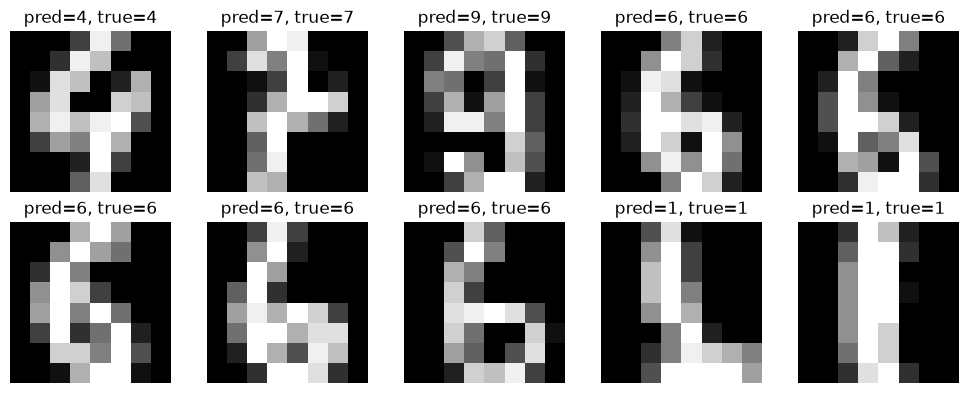

In [18]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
predictions = tiny_model.predict(X_tiny_test[:10])

for image, prediction, target, ax in zip(
    X_tiny_test[:10],
    predictions,
    y_tiny_test[:10].argmax(axis=1),
    axes.ravel(),
):
    ax.imshow(image.reshape(8, 8), cmap="gray")
    ax.set_title(f"pred={prediction}, true={target}")
    ax.axis("off")

plt.tight_layout()
plt.show()

### MNIST with 1,000 Training Images

MNIST contains $28\times28$ images, giving 784 input features. To expose the cost and limitations of full-batch learning, Lecture 7 trains on only the first 1,000 training images. The test set remains separate.

In [19]:
with np.load('../../datasets/mnist.npz') as mnist_data:
    X_mnist_train_full = mnist_data['x_train']
    y_mnist_train_full = mnist_data['y_train']
    X_mnist_test = mnist_data['x_test']
    y_mnist_test = mnist_data['y_test']

X_mnist_train = (
    X_mnist_train_full[:1_000].reshape(1_000, 28 * 28).astype("float32") / 255
)
y_mnist_train = np.eye(10)[y_mnist_train_full[:1_000]]

# A 2,000-image test subset keeps this instructional run quick.
X_mnist_test_small = (
    X_mnist_test[:2_000].reshape(2_000, 28 * 28).astype("float32") / 255
)
y_mnist_test_small = y_mnist_test[:2_000]

mnist_1k_model = MultilayerPerceptron([784, 32, 10], alpha=1.0, seed=1)
mnist_1k_history = mnist_1k_model.fit(
    X_mnist_train,
    y_mnist_train,
    validation_data=(
        X_mnist_test_small, np.eye(10)[y_mnist_test_small]
    ),
    epochs=200,
    update=20,
)
print(
    classification_report(
        y_mnist_test_small,
        mnist_1k_model.predict(X_mnist_test_small),
    )
)

  epoch         loss     val_loss     accuracy   val_accuracy
---------------------------------------------------------------
      1     2.252047     2.281291       0.2610         0.2210
     20     1.129604     1.305694       0.8150         0.6865
     40     0.661683     0.892923       0.8730         0.7530
     60     0.477723     0.731390       0.8970         0.7925
     80     0.380388     0.649612       0.9180         0.8040
    100     0.317589     0.601902       0.9260         0.8150
    120     0.272071     0.572041       0.9440         0.8225
    140     0.236699     0.552684       0.9520         0.8245
    160     0.208019     0.539949       0.9590         0.8310
    180     0.184147     0.531586       0.9640         0.8320
    200     0.163934     0.526210       0.9690         0.8330
              precision    recall  f1-score   support

           0       0.92      0.95      0.94       175
           1       0.93      0.98      0.96       234
           2       0.87      

# Lecture 8: Stochastic Gradient Descent and Regularization

Full-batch gradient descent computes one update from all $n$ examples. **Stochastic gradient descent (SGD)** estimates the gradient from a shuffled mini-batch $B$:

$$\nabla L_B(w)=\frac{1}{|B|}\sum_{i\in B}\nabla L_i(w).$$

The upgraded class below reuses the same explicit backpropagation equations but makes many smaller updates per epoch.

It also supports L2 regularization (weight decay):

$$L_{\mathrm{regularized}}(w)=L_{\mathrm{data}}(w)+\frac{\lambda}{2}\sum_{\ell}\|W^{(\ell)}\|_F^2.$$

The explicit weight gradient therefore gains $\lambda W^{(\ell)}$. Biases are not penalized.

In [20]:
class StochasticMultilayerPerceptron(MultilayerPerceptron):
    def __init__(
        self,
        layer_sizes,
        alpha=0.1,
        batch_size=64,
        l2=0.0,
        seed=1,
    ):
        super().__init__(layer_sizes, alpha=alpha, seed=seed)
        self.batch_size = batch_size
        self.l2 = l2

    def cross_entropy(self, X, y):
        data_loss = super().cross_entropy(X, y)
        # Penalize weights but not biases; 1/2 cancels during differentiation.
        penalty = 0.5 * self.l2 * sum(
            np.sum(W**2) for W in self.weights
        )
        return data_loss + penalty

    def gradients(self, X, y):
        weight_gradients, bias_gradients = super().gradients(X, y)

        for layer in range(len(weight_gradients)):
            # The derivative of (l2/2)||W||^2 is simply l2*W.
            weight_gradients[layer] += self.l2 * self.weights[layer]

        return weight_gradients, bias_gradients

    def fit(self, X, y, validation_data, epochs=10, update=1):
        X = np.asarray(X)
        y = np.asarray(y)
        history = []
        self.print_history_header()

        for epoch in range(epochs):
            # Shuffle once per epoch before slicing consecutive mini-batches.
            indices = self.rng.permutation(len(X))

            for start in range(0, len(X), self.batch_size):
                batch = indices[start : start + self.batch_size]
                # Each batch performs its own forward, backward, and update.
                self.step(X[batch], y[batch])

            if (epoch + 1) % update == 0 or epoch == 0:
                history.append(
                    self.record_metrics(epoch + 1, X, y, validation_data)
                )

        return history

### Full MNIST with Mini-batch SGD

The upgraded class now trains on all 60,000 MNIST training images. Each epoch uses every image once, but updates occur after each shuffled mini-batch rather than after the entire dataset.

In [21]:
X_mnist_train_full = (
    X_mnist_train_full.reshape(60_000, 28 * 28).astype("float32") / 255
)
X_mnist_test_full = (
    X_mnist_test.reshape(10_000, 28 * 28).astype("float32") / 255
)
y_mnist_train_full_one_hot = np.eye(10)[y_mnist_train_full]

sgd_model = StochasticMultilayerPerceptron(
    [784, 32, 16, 10],
    alpha=0.5,
    batch_size=64,
    l2=1e-5,
    seed=1,
)
sgd_history = sgd_model.fit(
    X_mnist_train_full,
    y_mnist_train_full_one_hot,
    validation_data=(X_mnist_test_full, np.eye(10)[y_mnist_test]),
    epochs=10,
    update=1,
)
print(classification_report(y_mnist_test, sgd_model.predict(X_mnist_test_full)))

  epoch         loss     val_loss     accuracy   val_accuracy
---------------------------------------------------------------
      1     0.347623     0.340837       0.9043         0.9017
      2     0.237904     0.237080       0.9320         0.9312
      3     0.177360     0.187532       0.9510         0.9479
      4     0.155409     0.171438       0.9570         0.9521
      5     0.133111     0.153562       0.9629         0.9555
      6     0.120563     0.140781       0.9671         0.9598
      7     0.111583     0.137197       0.9692         0.9616
      8     0.101861     0.129533       0.9729         0.9624
      9     0.104144     0.135783       0.9708         0.9612
     10     0.086969     0.123174       0.9776         0.9644
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.98      0.99      0.98      1135
           2       0.97      0.96      0.96      1032
           3       0.95      0.97    

## Code Takeaways

- Backpropagation reuses cached forward-pass values and propagates output error backward one layer at a time.
- Each weight gradient is an outer product of the previous activation and the current layer error; bias gradients sum the errors across examples.
- The tiny MNIST example makes individual tensors inspectable before the same implementation is applied to 1,000 examples.
- Mini-batch SGD updates parameters many times per epoch, unlike full-batch gradient descent.
- Shuffling prevents every epoch from presenting mini-batches in the same order.
- L2 regularization adds a weight-dependent term to both the loss and gradient, discouraging unnecessarily large weights.
- Printing training and validation metrics together makes optimization failure and overfitting distinguishable.